In [113]:
import requests
import pandas as pd
import numpy as np
import io
from nba_api.stats.static import teams
from nba_api.stats.endpoints import leaguegamefinder
from nba_api.stats.endpoints import PlayByPlayV2
import matplotlib.pyplot as plt



In [114]:
# Headers to help establish connection
headers  = {
    'Connection': 'keep-alive',
    'Accept': 'application/json, text/plain, */*',
    'x-nba-stats-token': 'true',
    'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/79.0.3945.130 Safari/537.36',
    'x-nba-stats-origin': 'stats',
    'Sec-Fetch-Site': 'same-origin',
    'Sec-Fetch-Mode': 'cors',
    'Referer': 'https://stats.nba.com/',
    'Accept-Encoding': 'gzip, deflate, br',
    'Accept-Language': 'en-US,en;q=0.9',
}

In [115]:
# Team Information DataFrame
import pandas as pd

team_info = pd.DataFrame({
    "teamTricode": [
        "ATL","BOS","BKN","CHA","CHI","CLE","DAL","DEN","DET","GSW",
        "HOU","IND","LAC","LAL","MEM","MIA","MIL","MIN","NOP","NYK",
        "OKC","ORL","PHI","PHX","POR","SAC","SAS","TOR","UTA","WAS"
    ],
    "teamName": [
        "Hawks","Celtics","Nets","Hornets","Bulls","Cavaliers","Mavericks",
        "Nuggets","Pistons","Warriors","Rockets","Pacers","Clippers",
        "Lakers","Grizzlies","Heat","Bucks","Timberwolves","Pelicans",
        "Knicks","Thunder","Magic","76ers","Suns","Trail Blazers","Kings",
        "Spurs","Raptors","Jazz","Wizards"
    ],
    "teamLocation": [
        "Atlanta","Boston","Brooklyn","Charlotte","Chicago","Cleveland",
        "Dallas","Denver","Detroit","Golden State","Houston","Indiana",
        "Los Angeles","Los Angeles","Memphis","Miami","Milwaukee",
        "Minnesota","New Orleans","New York","Oklahoma City","Orlando",
        "Philadelphia","Phoenix","Portland","Sacramento","San Antonio",
        "Toronto","Utah","Washington"
    ],
    "primaryColor": [
        "#E03A3E","#007A33","#000000","#1D1160","#CE1141","#860038",
        "#00538C","#0E2240","#C8102E","#1D428A","#CE1141","#002D62",
        "#C8102E","#552583","#5D76A9","#98002E","#00471B","#0C2340",
        "#0C2340","#006BB6","#007AC1","#0077C0","#006BB6","#1D1160",
        "#E03A3E","#5A2D81","#C4CED4","#CE1141","#002B5C","#002B5C"
    ],
    "secondaryColor": [
        "#FDB927","#BA9653","#FFFFFF","#00788C","#000000","#FDBB30",
        "#B8C4CA","#FEC524","#1D42BA","#FFC72C","#000000","#FDBB30",
        "#1D428A","#FDB927","#12173F","#F9A01B","#EEE1C6","#78BE20",
        "#C8102E","#F58426","#EF3B24","#C4CED4","#ED174C","#E56020",
        "#000000","#63727A","#000000","#000000","#00471B","#E31837"
    ]
})

In [116]:
# GLOBAL VARIABLES

quarter_ends = np.arange(720, 2881, 720)

In [117]:
from nba_api.stats.endpoints import playbyplayv3
from nba_api.stats.endpoints import boxscoresummaryv3

@st.cache_data

def load_game(game_id):

    pbp = playbyplayv3.PlayByPlayV3(
        game_id=game_id,
        start_period=1,
        end_period=4
    )

    df = pbp.get_data_frames()[0]
    df = pbp_features(df)

    bs = (
        boxscoresummaryv3
        .BoxScoreSummaryV3(game_id=game_id)
        .get_data_frames()[0]
    )

    team_info_df = create_team_info_df(
        bs,
        df,
        team_info
    )

    return df, bs, team_info_df


df, bs, team_info_df = load_game(game_id)

'\n\ngamefinder = leaguegamefinder.LeagueGameFinder(season_nullable=\'2020-21\', \n                                              league_id_nullable=\'00\', \n                                              season_type_nullable=\'Regular Season\')\ngames = gamefinder.get_data_frames()[0]\n# Get a list of distinct game ids \ngame_ids = games[\'GAME_ID\'].unique().tolist()\n# create function that gets pbp logs from the 2020-21 season\ndef get_data(game_id):\n    url = f"https://cdn.nba.com/static/json/liveData/playbyplay/playbyplay_{game_id}.json"\n\n    r = requests.get(url, headers=headers)\n\n    if r.status_code != 200:\n        print(f"{game_id}: HTTP {r.status_code}")\n        return None\n\n    try:\n        response = r.json()\n    except Exception:\n        print(f"{game_id}: invalid JSON")\n        print(r.text[:200])\n        return None\n\n    play_by_play = response["game"]["actions"]\n\n    df = pd.DataFrame(play_by_play)\n    df["gameid"] = game_id\n\n    return df\n\n'

In [155]:
from nba_api.stats.endpoints import boxscoresummaryv3

# Retrieve play-by-play data
game_id1 = "0022300001"  
game_id2 = "0022501174"

pbp = playbyplayv3.PlayByPlayV3(
    game_id=game_id1,
    start_period=1,
    end_period=4
)

new_pbp = playbyplayv3.PlayByPlayV3(
    game_id=game_id2,
    start_period=1,
    end_period=4
)
new_df = new_pbp.get_data_frames()[0]
df = pbp.get_data_frames()[0]
print(df.head())


# Retreive box score summary 
bs = boxscoresummaryv3.BoxScoreSummaryV3(game_id='0022300001').get_data_frames()[0]
new_bs = boxscoresummaryv3.BoxScoreSummaryV3(game_id='0022501174').get_data_frames()[0]
bs.columns

       gameId  actionNumber        clock  period      teamId teamTricode  \
0  0022300001             2  PT12M00.00S       1           0               
1  0022300001             4  PT12M00.00S       1  1610612754         IND   
2  0022300001             7  PT11M41.00S       1  1610612754         IND   
3  0022300001             9  PT11M23.00S       1  1610612739         CLE   
4  0022300001            10  PT11M20.00S       1  1610612754         IND   

   personId playerName playerNameI  xLegacy  ...  scoreHome  scoreAway  \
0         0                               0  ...          0          0   
1   1626167     Turner   M. Turner        0  ...                         
2   1626167     Turner   M. Turner        2  ...          2          0   
3   1630596     Mobley   E. Mobley       59  ...                         
4   1626167     Turner   M. Turner        0  ...                         

  pointsTotal  location                                        description  \
0           0       

Index(['gameId', 'gameCode', 'gameStatus', 'gameStatusText', 'period',
       'gameClock', 'gameTimeUTC', 'gameEt', 'awayTeamId', 'homeTeamId',
       'duration', 'attendance', 'sellout'],
      dtype='object')

In [119]:
from utils.time_conversion import period_seconds
from utils.time_conversion import game_seconds


def pbp_features(df): 
  df['gameTime'] = df.apply(
      lambda row: game_seconds(row['period'], row['clock']),
      axis=1
  )

  df = df.sort_values('gameTime')

  # Populate each time value with an associated score

  # Home team
  df['scoreHome'] = (
      pd.to_numeric(df['scoreHome'], errors='coerce')
        .ffill()
        .fillna(0)
  )

  # Away team
  df['scoreAway'] = (
      pd.to_numeric(df['scoreAway'], errors='coerce')
        .ffill()
        .fillna(0)
  )

  df['homeMargin'] = df['scoreHome'] - df['scoreAway']
  df['awayMargin'] = df['scoreAway'] - df['scoreHome']

  df['periodTime'] = df['clock'].apply(period_seconds) 

  return df

df = pbp_features(df)
new_df = pbp_features(new_df)

In [120]:
''' 
Team Information
'''

from utils.game_info import label_home_away
from utils.game_info import create_team_info_df



team_info_df = create_team_info_df(bs, df, team_info)
new_team_info_df = (new_bs, new_df, team_info)

print(team_info_df)


  teamTricode   teamName teamLocation      teamId  side  isHome primaryColor  \
0         IND     Pacers      Indiana  1610612754  home    True      #002D62   
1         CLE  Cavaliers    Cleveland  1610612739  away   False      #860038   

  secondaryColor  
0        #FDBB30  
1        #FDBB30  


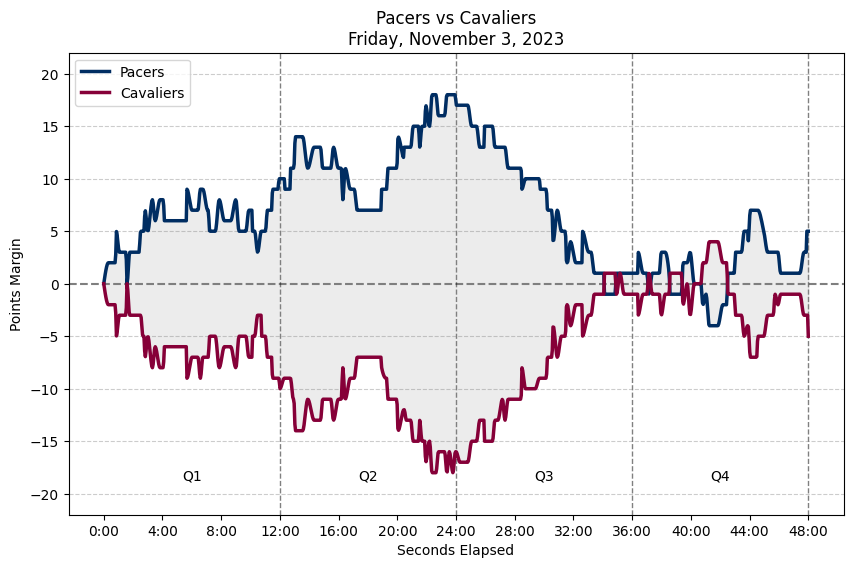

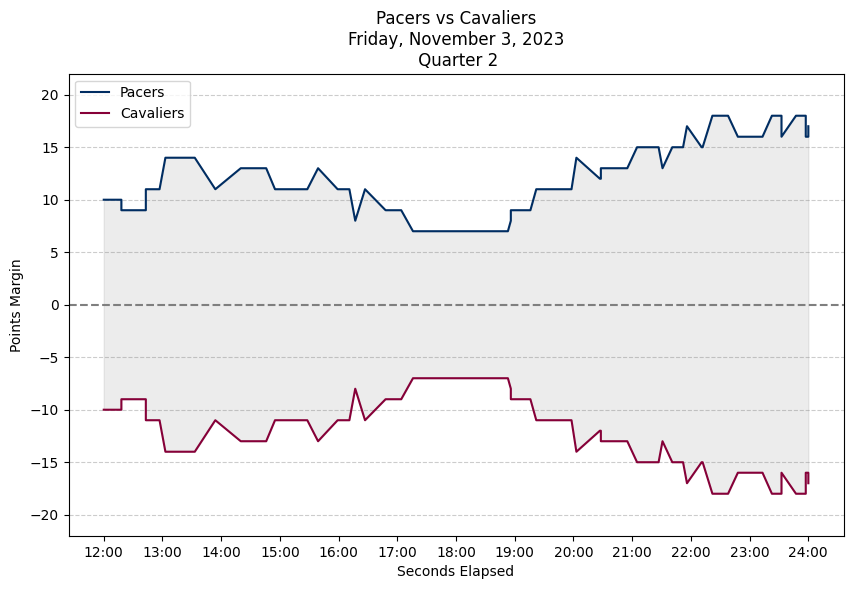

In [151]:
from matplotlib.ticker import FuncFormatter
from utils.time_conversion import seconds_to_minutes
from scipy.interpolate import make_interp_spline
from scipy.interpolate import PchipInterpolator
import numpy as np

def plot_total_scores(pbp, info, bs, period=0, score_type='total', smooth=False): 

    game_dt = pd.to_datetime(bs['GAME_DATE_EST'].iloc[0])
    
    # Extract data time components
    year = game_dt.year
    month = game_dt.strftime('%B') 
    day = game_dt.day
    day_of_week = game_dt.strftime('%A') 

    # Identify team info
    home_info = info.loc[info['isHome']].iloc[0]
    away_info = info.loc[~info['isHome']].iloc[0]

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.xaxis.set_major_formatter(FuncFormatter(seconds_to_minutes))

    # Subset period info
    if period == 0: 
        ax.set_xticks(np.arange(0, (4 * 720 + 1), 240)) 

        ax.set_title(f"{home_info['teamName']} vs {away_info['teamName']}\n{day_of_week}, {month} {day}, {year}")


        for x in quarter_ends:
            ax.axvline(x=x, color='gray', linestyle='--', linewidth=1, zorder=0)

        
        for i, x in enumerate(quarter_ends):
            ax.text(x - 360, ax.get_ylim()[1] - 20, f'Q{i+1}', ha='center', va='bottom')

    else:
        ax.set_xticks(np.arange((period - 1) * 720, (period * 720 + 1), 60)) 

        pbp = pbp[pbp['period'] == period]

        ax.set_title(f"{home_info['teamName']} vs {away_info['teamName']}\n{day_of_week}, {month} {day}, {year}\n Quarter {period}")

    

        
    # Total score: cumulative sum of both home and away points 
    if (score_type == 'total'):

        if smooth:

            # Clean data to remove duplicate time values
            home_clean = pbp.groupby('gameTime')['scoreHome'].max().reset_index()
            away_clean = pbp.groupby('gameTime')['scoreAway'].max().reset_index()

            # Create the Pchip objects 
            pchip_home = PchipInterpolator(home_clean['gameTime'], home_clean['scoreHome'])
            pchip_away = PchipInterpolator(away_clean['gameTime'], away_clean['scoreAway'])

            # 2880 is the standard 48-minute game in seconds
            x_smooth = np.linspace(0, pbp['gameTime'].max(), 1000)

            y_home_smooth = pchip_home(x_smooth)
            y_away_smooth = pchip_away(x_smooth)

            # Plot home
            ax.plot(
                x_smooth, y_home_smooth, 
                color=home_info['primaryColor'], 
                label=home_info['teamName'], 
                linewidth=2.5, 
                zorder=3
                )

            # Plot away
            ax.plot(
                x_smooth, y_away_smooth, 
                color=away_info['primaryColor'], 
                label=away_info['teamName'], 
                linewidth=2.5, 
                zorder=3
                )

        else: 

            ax.plot(pbp['gameTime'], pbp['scoreHome'], color=home_info['primaryColor'])
            ax.plot(pbp['gameTime'], pbp['scoreAway'], color=away_info['primaryColor'])
            
        ax.set_ylabel('Points Scored')

    # Marginal score: the difference inscore between both teams
    elif (score_type == 'marginal'):

        ax.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1.5, zorder=1)

        if smooth:

            # Clean data to remove duplicate time values
            home_clean = pbp.groupby('gameTime')['homeMargin'].max().reset_index()
            away_clean = pbp.groupby('gameTime')['awayMargin'].max().reset_index()

            # Create the Pchip objects 
            pchip_home = PchipInterpolator(home_clean['gameTime'], home_clean['homeMargin'])
            pchip_away = PchipInterpolator(away_clean['gameTime'], away_clean['awayMargin'])

            # 2880 is the standard 48-minute game in seconds
            x_smooth = np.linspace(0, pbp['gameTime'].max(), 1000)

            y_home_smooth = pchip_home(x_smooth)
            y_away_smooth = pchip_away(x_smooth)

            # Plot home
            ax.plot(
                x_smooth, y_home_smooth, 
                color=home_info['primaryColor'], 
                label=home_info['teamName'], 
                linewidth=2.5, 
                zorder=3
                )

            # Plot away
            ax.plot(
                x_smooth, y_away_smooth, 
                color=away_info['primaryColor'], 
                label=away_info['teamName'], 
                linewidth=2.5, 
                zorder=3
                )

        else: 

            ax.plot(pbp['gameTime'], pbp['homeMargin'], color=home_info['primaryColor'], label=home_info['teamName'])
            ax.plot(pbp['gameTime'], pbp['awayMargin'], color=away_info['primaryColor'], label=away_info['teamName'])

        ax.set_ylabel('Points Margin')

        ymin, ymax = ax.get_ylim()

        start = 5 * np.floor(ymin / 5)
        end = 5 * np.ceil(ymax / 5)

        for y in np.arange(start, end + 5, 5):
            if y != 0:  # keep the zero line distinct
                ax.axhline(
                    y=y,
                    color='gray',
                    linestyle='--',
                    linewidth=0.8,
                    alpha=0.4,
                    zorder=0
                )

        # Shade area between margins
        if smooth:
            ax.fill_between(
                x_smooth,
                y_home_smooth,
                y_away_smooth,
                color='gray',
                alpha=0.15,
                zorder=1
            )
        else:
            ax.fill_between(
                pbp['gameTime'],
                pbp['homeMargin'],
                pbp['awayMargin'],
                color='gray',
                alpha=0.15,
                zorder=1
            )

    
    
    ax.set_xlabel('Seconds Elapsed')
    ax.legend()
    
    return fig


plot_total_scores(df, team_info_df, bs, smooth=True, score_type='marginal')
plot_total_scores(df, team_info_df, bs, score_type='marginal', period=2)

In [122]:
def quarter_totals(pbp):
    # Group by period and take the last row of each group - captures missing end times
    q_totals = pbp.groupby('period').tail(1)
    
    return q_totals[['period', 'scoreHome', 'scoreAway', 'teamTricode']].reset_index(drop=True)

def create_tricode_pivot(totals, info_df):
    # Get tricodes team_info_df
    home_tri = info_df.loc[info_df['isHome'], 'teamTricode'].iloc[0]
    away_tri = info_df.loc[~info_df['isHome'], 'teamTricode'].iloc[0]

    # Replace 'home' / 'away' with associated TriCode
    totals_renamed = totals.rename(columns={
        'scoreHome': home_tri,
        'scoreAway': away_tri
    })

    # Add TriCodes into df
    melted = totals_renamed.melt(
        id_vars=['period'], 
        value_vars=[home_tri, away_tri], 
        var_name='Team', 
        value_name='Points'
    )

    # Pivot df for readability
    pivot_df = melted.pivot_table(
        index='Team', 
        columns='period', 
        values='Points'
    )
    
    return pivot_df.astype(int)

totals = quarter_totals(df)
final_table = create_tricode_pivot(totals, team_info_df)
print(final_table)


period   1   2   3    4
Team                   
CLE     26  53  87  116
IND     36  70  88  121


In [123]:
def find_largest_lead(pbp_df, info_df, period=0):

    home_tri = info_df.loc[info_df['isHome'], 'teamTricode'].iloc[0]
    away_tri = info_df.loc[~info_df['isHome'], 'teamTricode'].iloc[0]

    home_largest_lead, away_largest_lead = 0, 0
    home_lead_time, away_lead_time = 0, 0

    if period != 0:
        mask = pbp_df['period'] == period
        df = pbp_df[mask]

    else: 
        df = pbp_df

    for _, row in df.iterrows():
        # Home lead
        if row['scoreHome'] > row['scoreAway']:
            home_lead = row['scoreHome'] - row['scoreAway']

            if home_lead > home_largest_lead:
                home_largest_lead = home_lead
                home_lead_time = row['gameTime']

        # Away lead
        elif row['scoreHome'] < row['scoreAway']:
            away_lead = row['scoreAway'] - row['scoreHome']

            if away_lead > away_largest_lead:
                away_largest_lead = away_lead
                away_lead_time = row['gameTime']

    home_timestamp = seconds_to_minutes(home_lead_time)
    away_timestamp = seconds_to_minutes(away_lead_time)

    return pd.DataFrame({
        'Team': [home_tri, away_tri],
        'Largest Lead': [int(home_largest_lead), int(away_largest_lead)],
        'Time of Lead': [home_timestamp, away_timestamp]
    }).set_index('Team')


find_largest_lead(df, team_info_df)
        


,Largest Lead,Time of Lead
Team,,
IND,18,22:22
CLE,4,41:15


In [124]:
def find_largest_run(pbp_df, info_df, period=0):

    home_tri = info_df.loc[info_df['isHome'], 'teamTricode'].iloc[0]
    away_tri = info_df.loc[~info_df['isHome'], 'teamTricode'].iloc[0]

    # Best runs found so far
    home_max_run, away_max_run = 0, 0
    home_best_times, away_best_times = (0, 0), (0, 0)

    # Current active runs
    curr_home_run, curr_away_run = 0, 0
    curr_home_start, curr_away_start = 0, 0

    h_prev, a_prev = 0, 0

    df = pbp_df[pbp_df['period'] == period] if period != 0 else pbp_df

    for _, row in df.iterrows():
        sh, sa, time = row['scoreHome'], row['scoreAway'], row['gameTime']

        # Home scores
        if sh > h_prev:
            points = sh - h_prev
            # End away run
            curr_away_run = 0 
            
            # If home wasn't already on a run, start the clock
            if curr_home_run == 0:
                curr_home_start = time
            
            curr_home_run += points
            
            # Check if this is a new record
            if curr_home_run > home_max_run:
                home_max_run = curr_home_run
                home_best_times = (curr_home_start, time)
            
            h_prev = sh

        # Away scores
        if sa > a_prev:
            points = sa - a_prev
            # End home run
            curr_home_run = 0
            
            # If away wasn't already on a run, start the clock
            if curr_away_run == 0:
                curr_away_start = time
                
            curr_away_run += points
            
            # Check if this is a new record
            if curr_away_run > away_max_run:
                away_max_run = curr_away_run
                away_best_times = (curr_away_start, time)
            
            a_prev = sa

    # Helper to format the tuple of times
    fmt = lambda t: f"{seconds_to_minutes(t[0], None)} - {seconds_to_minutes(t[1], None)}"

    return pd.DataFrame({
        'Team': [home_tri, away_tri],
        'Largest Run': [int(home_max_run), int(away_max_run)],
        'Run Duration': [fmt(home_best_times), fmt(away_best_times)]
    }).set_index('Team')

find_largest_run(df, team_info_df)

,Largest Run,Run Duration
Team,,
IND,9,42:11 - 43:38
CLE,6,23:57 - 25:37


In [125]:
def find_lead_changes(pbp_df, info_df, period=0):

    home_tri = info_df.loc[info_df['isHome'], 'teamTricode'].iloc[0]
    away_tri = info_df.loc[~info_df['isHome'], 'teamTricode'].iloc[0]

    # Current active runs
    lead_changes = 0
    leader = 0 # indicates team leading (0 = neither, 1 = home, 2 = away)
    lead_time = [] # list of game time at lead change
    lead_score = [] # list of score at lead change

    df = pbp_df[pbp_df['period'] == period] if period != 0 else pbp_df

    for _, row in df.iterrows():
        sh, sa, time = row['scoreHome'], row['scoreAway'], row['gameTime']

        # Determine current leader
        if sh > sa: 
            curr_leader = 1
        elif sa > sh: 
            curr_leader = 2
        else: 
            curr_leader = 0
            

        
        # If lead changes
        if (curr_leader != leader) & (curr_leader != 0) & (leader != 0):
            
            leader = curr_leader
            lead_changes += 1
            lead_time.append(time)
            lead_score.append((sh, sa))

        # If the game becomes untied, update leader
        elif (leader == 0) & (curr_leader != 0):
            leader = curr_leader

        # If the game becomes tied, set leader to 0 so the next score counts as a change
        elif curr_leader == 0:
            leader = 0

    lead_formatted_times = [seconds_to_minutes(t, None) for t in lead_time]
    score_home = [sh[0] for sh in lead_score]
    score_away = [sa[1] for sa in lead_score]

    return lead_changes, pd.DataFrame({
        'Time' : lead_formatted_times,
        f'{home_tri} Score' : score_home,
        f'{away_tri} Score' : score_away
    })

find_lead_changes(df, team_info_df)

(8,
     Time  IND Score  CLE Score
 0  34:07       84.0       85.0
 1  34:56       86.0       85.0
 2  35:26       88.0       87.0
 3  37:09       90.0       91.0
 4  37:22       92.0       91.0
 5  38:35       94.0       95.0
 6  39:28       97.0       95.0
 7  42:32      106.0      105.0)

In [139]:
print(df.head())
df.columns



       gameId  actionNumber        clock  period      teamId teamTricode  \
0  0022300001             2  PT12M00.00S       1           0               
1  0022300001             4  PT12M00.00S       1  1610612754         IND   
2  0022300001             7  PT11M41.00S       1  1610612754         IND   
3  0022300001             9  PT11M23.00S       1  1610612739         CLE   
4  0022300001            10  PT11M20.00S       1  1610612754         IND   

   personId playerName playerNameI  xLegacy  ...  \
0         0                               0  ...   
1   1626167     Turner   M. Turner        0  ...   
2   1626167     Turner   M. Turner        2  ...   
3   1630596     Mobley   E. Mobley       59  ...   
4   1626167     Turner   M. Turner        0  ...   

                                         description   actionType  \
0                  Start of 1st Period (7:11 PM EST)       period   
1          Jump Ball Turner vs. Allen: Tip to Toppin    Jump Ball   
2  Turner 2' Cutting Du

Index(['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode',
       'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy',
       'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway',
       'pointsTotal', 'location', 'description', 'actionType', 'subType',
       'videoAvailable', 'shotValue', 'actionId', 'gameTime', 'homeMargin',
       'awayMargin', 'periodTime'],
      dtype='object')

In [127]:
def largest_player_runs(pbp, team_info, threshold=8):
    prev_player = None
    # determine total points scored on run, previous total points and the start time of the run
    run_total, prev_pts_total, run_start_time = 0, 0, 0
    last_score_time = 0
    
    runs_list = []

    for _, row in pbp.iterrows():
        player = row['playerNameI']
        
        # Calculate points scored on this specific play
        # Use shotValue for FGs; for FTs, only calculate diff if pointsTotal is currently non-zero
        if row['shotResult'] == 'Made':
            points = row['shotValue']
        elif row['pointsTotal'] > 0:
            points = row['pointsTotal'] - prev_pts_total
        else:
            points = 0

        if points > 0: 
            # If the player changed, the previous player's run is officially over
            if (prev_player != player):
                
                # Check if the finished run meets the threshold
                if prev_player is not None and run_total >= threshold:
                    runs_list.append({
                        'Player': prev_player,
                        'Run Total': int(run_total),
                        'Start Time': seconds_to_minutes(run_start_time, None),
                        'End Time': seconds_to_minutes(last_score_time, None)
                    })
                
                # Start new tracking for the current player
                prev_player = player
                run_total = points
                run_start_time = row['gameTime']
            else: 
                # Same player is still scoring
                run_total += points
            
            # Update the time of the most recent bucket in this run
            last_score_time = row['gameTime']
            
            # Update prev_pts_total ONLY when a score happens to keep it as a valid reference
            prev_pts_total = row['pointsTotal']
        

    # Final check for an active run when the game ends
    if prev_player is not None and run_total >= threshold:
        runs_list.append({
            'Player': prev_player,
            'Run Total': int(run_total),
            'Start Time': seconds_to_minutes(run_start_time, None),
            'End Time': seconds_to_minutes(last_score_time, None)
        })

    # Convert to DataFrame and drop any rows where Player might be None/NaN
    df_runs = pd.DataFrame(runs_list)
    
    return df_runs

final_runs = largest_player_runs(df, team_info_df, threshold=4)
final_runs2 = largest_player_runs(new_df, new_team_info_df, threshold=4)
print(final_runs2)

           Player  Run Total Start Time End Time
0    P. Pritchard          5       9:56    11:00
1        J. Oduro          4      12:34    13:01
2        L. Garza          5      14:39    15:14
3        J. Brown          4      20:56    21:08
4        J. Fears          5      23:11    23:30
5       S. Hauser          6      25:07    26:03
6        D. Queen          4      29:12    29:56
7        D. Queen          4      31:36    32:14
8   B. Scheierman          6      33:45    34:26
9      J. Hawkins          4      39:20    39:36
10       J. Oduro          4      43:07    43:37
11       J. Fears          4      44:08    44:23


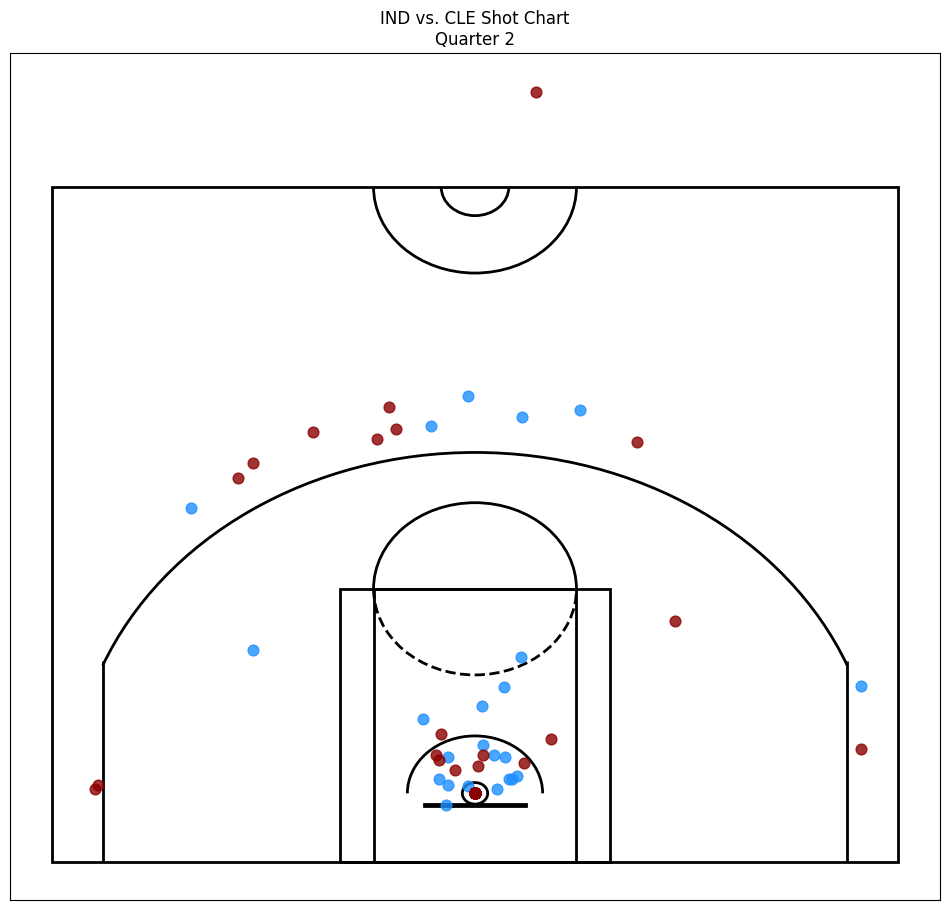

In [152]:
from utils.shot_chart import draw_court

def create_shot_chart(pbp_df, info_df, period=0, shot_result=''): 

    home_tri = info_df.loc[info_df['isHome'], 'teamTricode'].iloc[0]
    away_tri = info_df.loc[~info_df['isHome'], 'teamTricode'].iloc[0]

    if period != 0:
        filt_df = pbp_df[pbp_df['period'] == period]
    else:
        filt_df = pbp_df

    made = filt_df['shotResult'] == 'Made'

    x_made = filt_df[made]['xLegacy']
    x_missed = filt_df[~made]['xLegacy']
    y_made = filt_df[made]['yLegacy']
    y_missed = filt_df[~made]['yLegacy']

    plt.figure(figsize=(12, 11))
    ax = draw_court(outer_lines=True)

    pbp_df

    if shot_result == 'Made' or shot_result == '':
        plt.scatter(x_made, y_made, 
                s=60, 
                color='dodgerblue', 
                edgecolors='dodgerblue', 
                zorder=5,   
                alpha=0.8)
        
    if shot_result == 'Missed' or shot_result == '':
        plt.scatter(x_missed, y_missed, 
                s=60, 
                color='darkred', 
                edgecolors='darkred', 
                zorder=5,   
                alpha=0.8)


    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

    if period == 0:
        plt.title(f"{home_tri} vs. {away_tri} Shot Chart")
    else: 
        plt.title(f"{home_tri} vs. {away_tri} Shot Chart\nQuarter {period}")

    plt.show()


create_shot_chart(df, team_info_df, period=2)

In [163]:
from nba_api.stats.endpoints import WinProbabilityPBP
import streamlit as st

custom_headers = {
    'Host': 'stats.nba.com',
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:135.0) Gecko/20100101 Firefox/135.0',
    'Accept': 'application/json, text/plain, */*',
    'Accept-Language': 'en-US,en;q=0.5',
    'Referer': 'https://www.nba.com/',
    'Origin': 'https://www.nba.com',
    'Connection': 'keep-alive',
}

def get_wp_df(game_id):
    try:
        wp = WinProbabilityPBP(game_id=game_id, headers=custom_headers, timeout=180)
        return wp.get_data_frames()[0]
    except Exception as e:
        print(f"Error: {e}")
        return None


def plot_wp(game_id):

    wp_df = get_wp_df(game_id)

wp_df = get_wp_df(game_id1)

wp_df.head()

Error: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))


AttributeError: 'NoneType' object has no attribute 'head'

In [171]:
df.columns

Index(['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode',
       'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy',
       'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway',
       'pointsTotal', 'location', 'description', 'actionType', 'subType',
       'videoAvailable', 'shotValue', 'actionId'],
      dtype='object')

0      0.000000
1      0.016667
2      0.049702
3      0.082639
4      0.098745
         ...   
499   -4.159517
500   -2.196631
501   -0.233746
502   -0.232314
503    0.000000
Name: momentum, Length: 504, dtype: float64


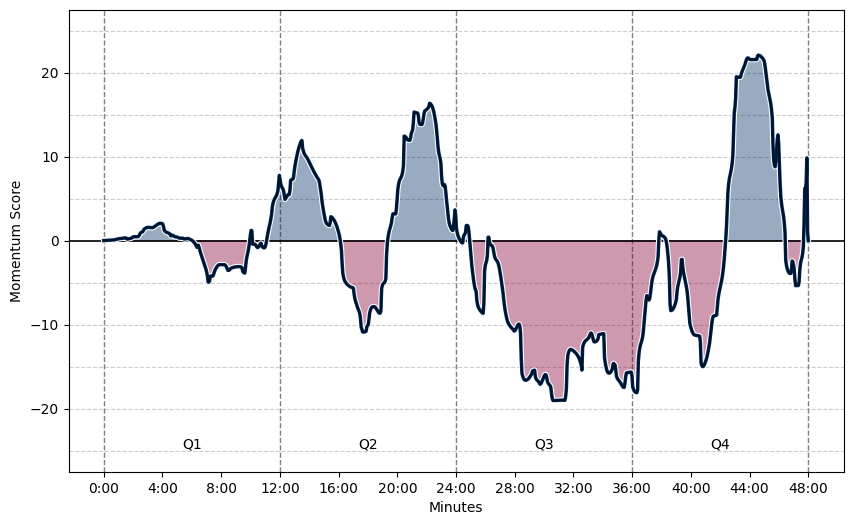

In [211]:
from utils.time_conversion import game_seconds
import matplotlib.patheffects as path_effects
import math

def calc_delta(pbp_df, info_df):

    home_tri = info_df.loc[info_df['isHome'], 'teamTricode'].iloc[0]
    away_tri = info_df.loc[~info_df['isHome'], 'teamTricode'].iloc[0]

    # Delta represents difference in points between previous play
    # Multiplier is 1 for HOME and -1 for AWAY 
    pbp_df['multiplier'] = np.where(pbp_df['teamTricode'] == home_tri, 1, -1)
    pbp_df['ptsDelta'] = (pbp_df['pointsTotal'] - pbp_df['pointsTotal'].shift(1)).fillna(0)
    pbp_df['ptsDelta'] *= pbp_df['multiplier']
        
    return pbp_df['ptsDelta']

def calc_momentum(pbp_df, info_df, threshold=300, decay=0.01, scaling=0.001):


    pbp_df['gameTime'] = pbp_df.apply(
        lambda row: game_seconds(
            row['period'],
            row['clock']
        ),
        axis=1
    )

    pbp_df['scoreDelta'] = calc_delta(pbp_df, info_df)

    momentum = []

    

    for _, row in pbp_df.iterrows():

        start = row['gameTime'] - threshold
        start = 0 if start < 0 else start
        end = row['gameTime']

        weights = []

        # Filter the PBP to the current window
        temp = pbp_df[(pbp_df['gameTime'] >= start) & (pbp_df['gameTime'] <= end)]

        # Weight = Delta * e^(-decay * (CurrentTime - EventTime))
        time_diffs = row['gameTime'] - temp['gameTime']
        weights = temp['scoreDelta'] * np.exp(-decay * time_diffs)

        weights_sum = weights.sum()

        # Scale values to prevent indefinite increases
        scaled_val = np.tanh(weights_sum * scaling) * 25
        momentum.append(scaled_val)


    momentum_series = pd.Series(momentum, index=pbp_df.index)
    momentum_series = momentum_series.rolling(window=3, center=True).mean().fillna(0)

    return momentum_series



print(df['momentum'])

def plot_momentum(pbp_df, info_df, period=0, smooth=True, threshold=300, decay=0.01, scaling=0.001): 

    pbp_df['momentum'] = calc_momentum(pbp_df, info_df, scaling=scaling, decay=decay, threshold=180)
     
    quarter_ends = np.arange(720, 2881, 720)
    quarters = np.arange(0, 2881, 720)

    # Identify team info
    home_info = info_df.loc[info_df['isHome']].iloc[0]
    away_info = info_df.loc[~info_df['isHome']].iloc[0]

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.xaxis.set_major_formatter(FuncFormatter(seconds_to_minutes))

    # Subset period info
    if period == 0: 
        ax.set_xticks(np.arange(0, (4 * 720 + 1), 240)) 

        # ax.set_title(f"{home_info['teamName']} vs {away_info['teamName']}\n{get_game_date(bs)}")

        for x in quarters:
            ax.axvline(x=x, color='gray', linestyle='--', linewidth=1, zorder=0)

        
        for i, x in enumerate(quarter_ends):
            ax.text(x - 360, -25, f'Q{i+1}', ha='center', va='bottom')

        new_pbp_df = pbp_df.copy()

    else:

        ax.set_xticks(np.arange((period - 1) * 720, (period * 720 + 1), 60)) 

        new_pbp_df = pbp_df[pbp_df['period'] == period]

        # x limits
        quarter_start = (period - 1) * 720
        quarter_end = period * 720

        ax.set_xlim(quarter_start, quarter_end) 

    if smooth:

        # Clean data to remove duplicate time values
        pbp_df_clean = new_pbp_df.groupby('gameTime')['momentum'].max().reset_index()
        

        # Create the Pchip objects 
        pchip = PchipInterpolator(pbp_df_clean['gameTime'], pbp_df_clean['momentum'])
        

        # 2880 is the standard 48-minute game in seconds
        # Consider subsetted games can vary in length
        x_smooth = np.linspace(
            new_pbp_df['gameTime'].min(),
            new_pbp_df['gameTime'].max(),
            1000
        )

        y_smooth = pchip(x_smooth)

        # Adjust colour based upon +/- 
        ax.plot(x_smooth, y_smooth, color=home_info['primaryColor'], linewidth=2.5, zorder=3, 
                path_effects=[plt.matplotlib.patheffects.withStroke(linewidth=4, foreground='white')],
                label=home_info['teamTricode']) # Placeholder label logic
        
        # Overlay the line with the color logic using fill_between or masked arrays for complex colors
        ax.fill_between(x_smooth, y_smooth, 0, where=(y_smooth >= 0), color=home_info['primaryColor'], alpha=0.4, interpolate=True, zorder=2)
        ax.fill_between(x_smooth, y_smooth, 0, where=(y_smooth < 0), color=away_info['primaryColor'], alpha=0.4, interpolate=True, zorder=2)
        
        # Keep a neutral black line for the boundary to ensure clarity
        ax.plot(x_smooth, y_smooth, color="black", linewidth=1.5, zorder=3, alpha=0.6)

    else: 
        # Adjust colour based upon +/- 
        x_raw = new_pbp_df['gameTime']
        y_raw = new_pbp_df['momentum']
        
        ax.fill_between(x_raw, y_raw, 0, where=(y_raw >= 0), color=home_info['primaryColor'], alpha=0.4, interpolate=True, zorder=2)
        ax.fill_between(x_raw, y_raw, 0, where=(y_raw < 0), color=away_info['primaryColor'], alpha=0.4, interpolate=True, zorder=2)
        ax.plot(x_raw, y_raw, color="black", linewidth=1.5, zorder=3, alpha=0.6)

    ax.set_ylabel('Momentum Score')

    # Grid the graph
    ymin, ymax = ax.get_ylim()

    start = 5 * np.floor(ymin / 5)
    end = 5 * np.ceil(ymax / 5)

    for y in np.arange(start, end + 5, 5):
        if y != 0:  # keep the zero line distinct (i.e remains black)
            ax.axhline(
                y=y,
                color='gray',
                linestyle='--',
                linewidth=0.8,
                alpha=0.4,
                zorder=0
            )
    
    # Ensure the zero line is prominent
    ax.axhline(0, color='black', linewidth=1.2, zorder=2)

    ax.set_xlabel('Minutes')
    # ax.legend()
    
    return fig

fig = plot_momentum(df, team_info_df, threshold=180, decay=.001, scaling=.001)

plt.show(fig)


Index(['gameId', 'gameCode', 'gameStatus', 'gameStatusText', 'period',
       'gameClock', 'gameTimeUTC', 'gameEt', 'awayTeamId', 'homeTeamId',
       'duration', 'attendance', 'sellout'],
      dtype='object')

In [239]:
# https://github.com/swar/nba_api/blob/master/docs/nba_api/stats/endpoints/boxscoresummaryv3.md
from nba_api.stats.endpoints import BoxScoreAdvancedV3, BoxScoreTraditionalV3, BoxScorePlayerTrackV3, BoxScoreHustleV2, BoxScoreFourFactorsV3
import pandas as pd

def get_game_stats(game_id, types=['traditional']):
    """
    Fetches specific NBA boxscores based on a list of types.
    Supported types: 'traditional', 'adv', 'track' or 'all' (returns every df)
    """
    # Mapping keywords to the endpoint classes
    mapping = {
        'traditional': BoxScoreTraditionalV3,
        'adv': BoxScoreAdvancedV3,
        'track': BoxScorePlayerTrackV3,
        'hustle': BoxScoreHustleV2,
        'fourfactors': BoxScoreFourFactorsV3
    }
    
    player_results = {}
    team_results = {}

    if 'all' in types:
        new_types = ['traditional', 'adv', 'track', 'hustle', 'fourfactors']
    else:
        new_types = types


    for t in new_types:
        if t in mapping:
            # Initialize the endpoint and get the first dataframe (Player Stats)
            endpoint_class = mapping[t]
            player_results[t] = endpoint_class(game_id=game_id).get_data_frames()[0]
            team_results[t] = endpoint_class(game_id=game_id).get_data_frames()[1]
        else:
            print(f"Warning: Type '{t}' is not recognized.")

    return player_results, team_results


def get_game_highs(game_id, selected_stats=['all'], types=['traditional'], team='both'):
    # Fetch the data (Fixed variable name conflict) 
    # FIX: Allow more functionality - convert lines into a function
    all_stats = get_game_stats(game_id, types)
    traditional_bs = all_stats.get('traditional')

    if traditional_bs is None:
        return "Traditional Box Score not found in results."
    
    if team == 'both':
        filt_bs = traditional_bs
    else:
        filt_bs = traditional_bs[traditional_bs['teamTricode'] == team]

    stat_map = {
        'points': 'Points',
        'reboundsTotal': 'Rebounds',
        'assists': 'Assists',
        'steals': 'Steals',
        'blocks': 'Blocks',
        'turnovers': 'Turnovers'
    }

    # All selects all columns
    if 'all' in selected_stats:
        target_cols = list(stat_map.keys())
    # Choose selected coluns
    else: 
        target_cols = selected_stats

    game_highs = {}

    for c in target_cols:
        # Unsupported column names
        if c not in filt_bs.columns:
            continue
            
        idx = filt_bs[c].idxmax()

        first = filt_bs.loc[idx, 'firstName']
        last = filt_bs.loc[idx, 'familyName']
        team = filt_bs.loc[idx, 'teamTricode']
        total = filt_bs.loc[idx, c]
        
        display_name = stat_map.get(c, c.capitalize())
        game_highs[display_name] = {
            "Player": f"{first} {last}", 
            "Value": total, 
            "Team" : team
            }

    return pd.DataFrame(game_highs).T

get_game_highs(game_id1, team='CLE')

,Player,Value,Team
Points,Donovan Mitchell,38,CLE
Rebounds,Evan Mobley,10,CLE
Assists,Donovan Mitchell,9,CLE
Steals,Evan Mobley,3,CLE
Blocks,Evan Mobley,4,CLE
Turnovers,Darius Garland,4,CLE


In [237]:
stats = get_game_stats(game_id1, ['all'])

trad = stats.get('traditional')
adv = stats.get('adv')
track = stats.get('track')
hustle = stats.get('hustle')
fourfactors = stats.get('fourfactors')
adv.columns
track.columns
hustle.columns
fourfactors.columns

Index(['gameId', 'teamId', 'teamCity', 'teamName', 'teamTricode', 'teamSlug',
       'personId', 'firstName', 'familyName', 'nameI', 'playerSlug',
       'position', 'comment', 'jerseyNum', 'minutes', 'fieldGoalsMade',
       'fieldGoalsAttempted', 'fieldGoalsPercentage', 'threePointersMade',
       'threePointersAttempted', 'threePointersPercentage', 'freeThrowsMade',
       'freeThrowsAttempted', 'freeThrowsPercentage', 'reboundsOffensive',
       'reboundsDefensive', 'reboundsTotal', 'assists', 'steals', 'blocks',
       'turnovers', 'foulsPersonal', 'points', 'plusMinusPoints'],
      dtype='object')

In [240]:
fourfactors.columns

Index(['gameId', 'teamId', 'teamCity', 'teamName', 'teamTricode', 'teamSlug',
       'personId', 'firstName', 'familyName', 'nameI', 'playerSlug',
       'position', 'comment', 'jerseyNum', 'minutes',
       'effectiveFieldGoalPercentage', 'freeThrowAttemptRate',
       'teamTurnoverPercentage', 'offensiveReboundPercentage',
       'oppEffectiveFieldGoalPercentage', 'oppFreeThrowAttemptRate',
       'oppTeamTurnoverPercentage', 'oppOffensiveReboundPercentage'],
      dtype='object')

In [ ]:
def get_box_score(game_id, types='traditional', expanded=True): 

    cols_deselected = ['gameId', 'teamId', 'teamCity', 'teamName', 'teamSlug', 'personId', 'firstName', 'familyName', 'comment']

    player_info = ['nameI', 'teamTricode', 'position', 'jerseyNum']

    # Map only essential columns (non-expanded)
    col_mapping = {
        'traditional': ['minutes', 'points', 'reboundsTotal', 'assists', 'steals', 'blocks', 'turnovers'],
        'adv': ['minutes', 'offensiveRating', 'defensiveRating', 'netRating', 'trueShootingPercentage', 'assistToTurnover', 'usagePercentage'],
        'track': ['minutes', 'distance', 'touches', 'passes', 'contestedFieldGoalPercentage', 'uncontestedFieldGoalsPercentage'],
        'hustle': ['minutes', 'contestedShots', 'deflections', 'chargesDrawn', 'screenAssists', 'looseBallsRecoveredTotal', 'boxOuts'],
        'fourfactors': ['minutes', 'effectiveFieldGoalPercentage', 'freeThrowAttemptRate', 'teamTurnoverPercentage', 'offensiveReboundPercentage']
    }   

    # Dynamically access columns
    selected_cols = col_mapping.get(types, [])

    stats = get_game_stats(game_id, [types])
    final_cols = player_info + selected_cols

    df = stats.get(types)

    if expanded == True:
        # Return full column set
        filt_df = df[~cols_deselected]
    else: 
        # Obtain specific [relevant] columns
        filt_df = final_cols

    return filt_df


In [244]:
def game_summary(team_bs_dict, info_df): 

    home_tri = info_df.loc[info_df['isHome'], 'teamTricode'].iloc[0]
    away_tri = info_df.loc[~info_df['isHome'], 'teamTricode'].iloc[0]

    traditional_team_bs = team_bs_dict.get('traditional')


,scoreHome,scoreAway
0,0,0
1,,
2,2,0
3,,
4,,
...,...,...
494,,
495,,
496,120,116
497,,


In [248]:
from nba_api.stats.endpoints import teamgamelogs
import pandas as pd

def load_matchups(game_date, team_id, opp_id, headers, last=5): 
    """
    game_date: string 'MM/DD/YYYY'
    team_id: NBA Team ID
    last: Number of previous games to retrieve
    """
    
    # 1. Fetch the logs
    # We use date_to_nullable to "look back" from that date
    log = teamgamelogs.TeamGameLogs(
        team_id_nullable=team_id,
        opp_team_id_nullable=opp_id,
        date_to_nullable=game_date,
        last_n_games_nullable=last,
        headers=headers
    )
    
    df = log.get_data_frames()[0]

    # 2. Convert GAME_DATE to datetime for reliable sorting
    df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])
    
    # 3. Sort by date (Newest first)
    df = df.sort_values(by='GAME_DATE', ascending=False)
    
    # 4. Filter out the current game if it exists in the log 
    # (Sometimes dateTo is inclusive)
    target_dt = pd.to_datetime(game_date)
    df = df[df['GAME_DATE'] < target_dt]

    return df

game_date = bs['gameEt'].iloc[0]
home_team = bs['homeTeamId'].iloc[0]
away_team = bs['awayTeamId'].iloc[0]

matchups = load_matchups(game_date, home_team, away_team, headers, last=3)

matchups.head()

ReadTimeout: HTTPSConnectionPool(host='stats.nba.com', port=443): Read timed out. (read timeout=30)

In [254]:
from nba_api.stats.endpoints import leaguegamefinder

def load_matchups(game_date, team_id, opp_id, last_n=5):
    finder = leaguegamefinder.LeagueGameFinder(
        team_id_nullable=team_id,
        vs_team_id_nullable=opp_id,
        date_to_nullable=game_date
    )
    df = finder.get_data_frames()[0]
    return df.head(last_n)

matchups = load_matchups(game_date, home_team, away_team)

def prev_matchups(matchups): 

    deselected_cols = ['SEASON_ID', 'TEAM_ID', 'TEAM_NAME', 'GAME_ID', 'MIN', 'PLUS_MINUS'] # non-essential columns

    # mapping for column renaming
    mapping = {
        'FG_PCT': 'FG%',
        'FG3M': '3PM',
        'FG3A': '3PA',
        'FG3_PCT': '3PT%',
        'FT_PCT': 'FT%'
    }

    filt_df = matchups[~deselected_cols]

    filt_df.rename(columns=mapping, inplace=True)

    return filt_df 

In [261]:
bs.columns

Index(['gameId', 'gameCode', 'gameStatus', 'gameStatusText', 'period',
       'gameClock', 'gameTimeUTC', 'gameEt', 'awayTeamId', 'homeTeamId',
       'duration', 'attendance', 'sellout'],
      dtype='object')

In [262]:
trad.columns

Index(['gameId', 'teamId', 'teamCity', 'teamName', 'teamTricode', 'teamSlug',
       'personId', 'firstName', 'familyName', 'nameI', 'playerSlug',
       'position', 'comment', 'jerseyNum', 'minutes', 'fieldGoalsMade',
       'fieldGoalsAttempted', 'fieldGoalsPercentage', 'threePointersMade',
       'threePointersAttempted', 'threePointersPercentage', 'freeThrowsMade',
       'freeThrowsAttempted', 'freeThrowsPercentage', 'reboundsOffensive',
       'reboundsDefensive', 'reboundsTotal', 'assists', 'steals', 'blocks',
       'turnovers', 'foulsPersonal', 'points', 'plusMinusPoints'],
      dtype='object')

In [260]:
matchups.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS
0,22025,1610612754,IND,Indiana Pacers,0022501136,2026-04-05,IND @ CLE,L,240,108,...,0.862,12,31,43,28,7,1,10,15,-9.0
1,22025,1610612754,IND,Indiana Pacers,0022500510,2026-01-06,IND vs. CLE,L,241,116,...,0.737,7,25,32,32,10,4,11,14,-4.0
2,22025,1610612754,IND,Indiana Pacers,0022500310,2025-12-01,IND vs. CLE,L,242,119,...,0.730,14,22,36,19,5,6,14,22,-16.0
3,22025,1610612754,IND,Indiana Pacers,0022500048,2025-11-21,IND @ CLE,L,238,109,...,0.923,10,33,43,25,10,6,12,22,-11.0
4,42024,1610612754,IND,Indiana Pacers,0042400205,2025-05-13,IND @ CLE,W,239,114,...,0.773,5,42,47,26,8,8,13,27,9.0
